In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# **CNN PROJECT**

**Imports and Dataset Loading**

In [1]:
# Cell 1: Imports and dataset loading

import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

from torchvision.datasets import OxfordIIITPet

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

# Downloads into ./data/oxford-iiit-pet.
# Use split="trainval" for the provided training/validation portion.
dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
)

print(f"Number of samples: {len(dataset)}")

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


100%|██████████| 792M/792M [00:28<00:00, 28.2MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.6MB/s]


Number of samples: 3680


**Display several image/mask pairs and inspect their values**

Sample 0
  PIL image size (width, height): (394, 500)
  PIL mask size  (width, height): (394, 500)
  Image array shape (H, W, C):   (500, 394, 3)
  Mask array shape  (H, W):      (500, 394)
  Unique mask values:            [1 2 3]

Sample 100
  PIL image size (width, height): (333, 500)
  PIL mask size  (width, height): (333, 500)
  Image array shape (H, W, C):   (500, 333, 3)
  Mask array shape  (H, W):      (500, 333)
  Unique mask values:            [1 2 3]

Sample 500
  PIL image size (width, height): (500, 334)
  PIL mask size  (width, height): (500, 334)
  Image array shape (H, W, C):   (334, 500, 3)
  Mask array shape  (H, W):      (334, 500)
  Unique mask values:            [1 2 3]

Sample 1000
  PIL image size (width, height): (500, 375)
  PIL mask size  (width, height): (500, 375)
  Image array shape (H, W, C):   (375, 500, 3)
  Mask array shape  (H, W):      (375, 500)
  Unique mask values:            [1 2 3]



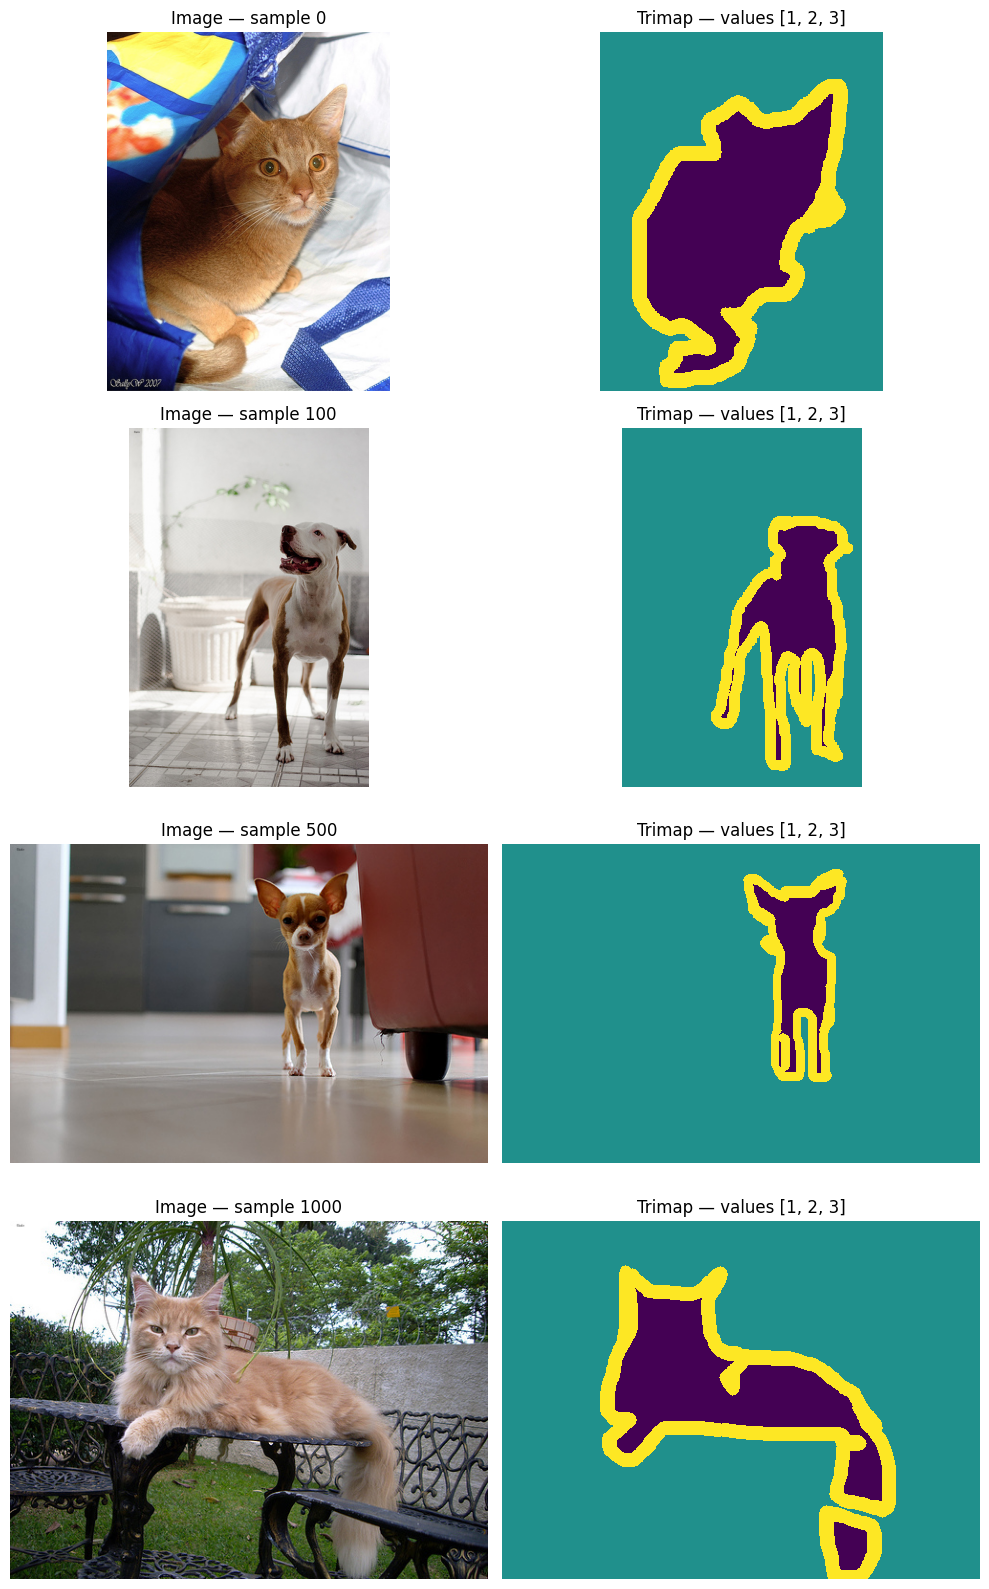

In [2]:
# Cell 2: Display several image/mask pairs and inspect their values

sample_indices = [0, 100, 500, 1000]

fig, axes = plt.subplots(
    nrows=len(sample_indices),
    ncols=2,
    figsize=(10, 4 * len(sample_indices)),
)

for row, index in enumerate(sample_indices):
    # Both objects are PIL images because no transforms were supplied.
    image, mask = dataset[index]

    # Convert to NumPy only for inspection and plotting.
    image_array = np.array(image)
    mask_array = np.array(mask)

    print(f"Sample {index}")
    print(f"  PIL image size (width, height): {image.size}")
    print(f"  PIL mask size  (width, height): {mask.size}")
    print(f"  Image array shape (H, W, C):   {image_array.shape}")
    print(f"  Mask array shape  (H, W):      {mask_array.shape}")
    print(f"  Unique mask values:            {np.unique(mask_array)}")
    print()

    axes[row, 0].imshow(image_array)
    axes[row, 0].set_title(f"Image — sample {index}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        mask_array,
        cmap="viridis",
        vmin=1,
        vmax=3,
        interpolation="nearest",
    )
    axes[row, 1].set_title(
        f"Trimap — values {np.unique(mask_array).tolist()}"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

**Dataset and DataLoader**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode


class PetSegmentationDataset(Dataset):
    """Oxford-IIIT Pet dataset prepared for binary segmentation."""

    def __init__(self, root="./data", split="trainval", image_size=(128, 128)):
        self.image_size = image_size

        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True,
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, mask = self.dataset[index]

        # Guarantee that every image has exactly three RGB channels.
        image = image.convert("RGB")

        # Images use bilinear interpolation because their pixel values are
        # continuous color measurements.
        image = TF.resize(
            image,
            self.image_size,
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        # Masks use nearest-neighbor interpolation so class IDs remain intact.
        mask = TF.resize(
            mask,
            self.image_size,
            interpolation=InterpolationMode.NEAREST,
        )

        # Convert RGB image to float tensor [3, H, W] in the range [0, 1].
        image_tensor = TF.to_tensor(image)

        # Convert the trimap from PIL to integer tensor [H, W].
        mask_array = np.array(mask, dtype=np.int64)
        mask_tensor = torch.from_numpy(mask_array)

        # Original values:
        #   1 = pet, 2 = background, 3 = border
        #
        # Binary values:
        #   0 = background
        #   1 = pet or border
        mask_tensor = (mask_tensor != 2).long()

        # Catch preprocessing errors early.
        assert image_tensor.shape == (3, 128, 128)
        assert mask_tensor.shape == (128, 128)

        return image_tensor, mask_tensor

In [ ]:
# Create the dataset and DataLoader.

train_dataset = PetSegmentationDataset(
    root="./data",
    split="trainval",
    image_size=(128, 128),
)

# Seeded generator makes shuffled ordering reproducible.
generator = torch.Generator().manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,  # Suitable for Kaggle and Colab
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    generator=generator,
)

print(f"Dataset size: {len(train_dataset)}")

In [ ]:
# Inspect one batch.

images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape: ", masks.shape)
print("Image dtype: ", images.dtype)
print("Mask dtype:  ", masks.dtype)
print("Image range: ", images.min().item(), "to", images.max().item())
print("Unique mask values:", torch.unique(masks).tolist())

In [ ]:
# Visualize one preprocessed image and mask.

image_to_show = images[0].permute(1, 2, 0).cpu().numpy()
mask_to_show = masks[0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(image_to_show)
axes[0].set_title("Preprocessed image")
axes[0].axis("off")

axes[1].imshow(
    mask_to_show,
    cmap="gray",
    vmin=0,
    vmax=1,
    interpolation="nearest",
)
axes[1].set_title("Binary mask\n0 = background, 1 = pet or border")
axes[1].axis("off")

plt.tight_layout()
plt.show()